# Wind Turbine CO2 Optimization Project

This project analyzes real-world wind data to evaluate turbine performance and environmental impact.

## 1. Data Loading

We import real-world wind data from Germany to analyze wind behavior and energy potential.


In [35]:
import pandas as pd
file_path = "../data/raw/produkt_ff_stunde_20241031_20260503_00303.txt"
df = pd.read_csv(file_path, sep=";")
df.head()
df.columns = df.columns.str.strip()
df.columns

Index(['STATIONS_ID', 'MESS_DATUM', 'QN_3', 'F', 'D', 'eor'], dtype='str')

## 2. Data Cleaning and Preparation

We clean the dataset by selecting relevant columns, renaming variables, and converting timestamps into a usable format.


In [36]:
wind_df = df[["MESS_DATUM", "F"]].copy()
wind_df = wind_df.rename(columns={
    "MESS_DATUM": "timestamp",
    "F": "wind_speed_m_s"
})

wind_df.head()

,timestamp,wind_speed_m_s
0,2024103100,3.7
1,2024103101,3.6
2,2024103102,3.7
3,2024103103,3.0
4,2024103104,2.0


We convert timestamps into datetime format and remove invalid wind speed values.

In [37]:
wind_df["timestamp"] = pd.to_datetime(
    wind_df["timestamp"],
    format="%Y%m%d%H"
)
wind_df.head()
wind_df.describe()
wind_df=wind_df[wind_df["wind_speed_m_s"]>=0]
wind_df.head()

,timestamp,wind_speed_m_s
0,2024-10-31 00:00:00,3.7
1,2024-10-31 01:00:00,3.6
2,2024-10-31 02:00:00,3.7
3,2024-10-31 03:00:00,3.0
4,2024-10-31 04:00:00,2.0


## 3. Wind Data Analysis

We analyze wind speed trends over time using daily averages to better understand variability and patterns.

In [38]:
import matplotlib.pyplot as plt
daily_wind=wind_df.resample("D").mean()
plt.figure(figsize=(10,5)) 
plt.plot(daily_wind.index, daily_wind["wind_speed_m_s"])
plt.title("Wind Speed Over Time") 
plt.xlabel("Time") 
plt.ylabel("Wind Speed (m/s)") 
plt.show()

TypeError: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'Index'

## 4. Basic Turbine Model

We create a simplified turbine model using a power curve based on wind speed.


In [ ]:
def wind_to_power(v):
    if v < 3:
        return 0
    elif v < 12:
        return (v - 3) / (12 - 3) * 1000
    elif v <= 25:
        return 1000
    else:
        return 0

wind_df["power_kw"] = wind_df["wind_speed_m_s"].apply(wind_to_power)

wind_df.head()


,wind_speed_m_s,power_kw
timestamp,,
2024-10-31 00:00:00,3.7,77.777778
2024-10-31 01:00:00,3.6,66.666667
2024-10-31 02:00:00,3.7,77.777778
2024-10-31 03:00:00,3.0,0.000000
2024-10-31 04:00:00,2.0,0.000000


We visualize the power output over time to observe energy generation behavior.


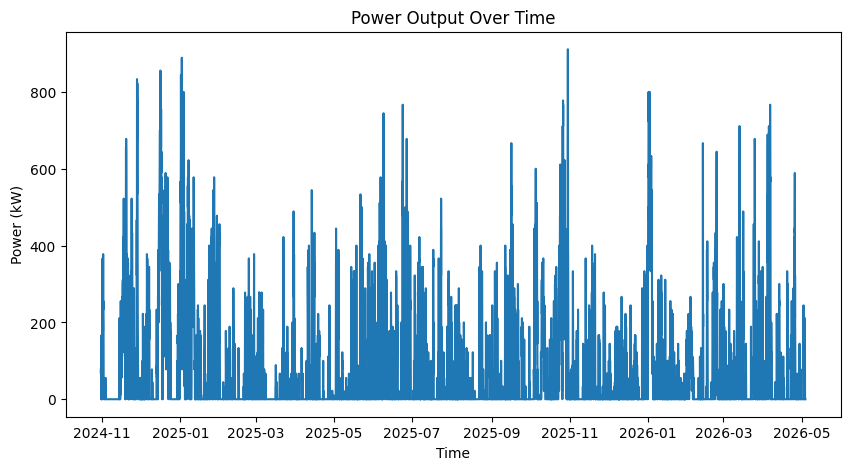

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(wind_df.index, wind_df["power_kw"])

plt.title("Power Output Over Time")
plt.xlabel("Time")
plt.ylabel("Power (kW)")

plt.show()


This model converts wind speed into power output based on turbine characteristics.


## 5. Advanced Turbine Modeling

We simulate multiple turbine designs using realistic parameters such as cut-in speed, rated speed, and cut-out speed.

In [ ]:
def turbine_power(v, cut_in, rated_speed, cut_out, rated_power):
    if v < cut_in:
        return 0
    elif v < rated_speed:
        return (v - cut_in) / (rated_speed - cut_in) * rated_power
    elif v <= cut_out:
        return rated_power
    else:
        return 0

We compare different turbine designs to evaluate their performance under the same wind conditions.


In [ ]:
wind_df["power_A_kw"] = wind_df["wind_speed_m_s"].apply(
    lambda v: turbine_power(v, cut_in=3, rated_speed=12, cut_out=25, rated_power=1000)
)

wind_df["power_B_kw"] = wind_df["wind_speed_m_s"].apply(
    lambda v: turbine_power(v, cut_in=2.5, rated_speed=10, cut_out=25, rated_power=900)
)

wind_df["power_C_kw"] = wind_df["wind_speed_m_s"].apply(
    lambda v: turbine_power(v, cut_in=3.5, rated_speed=11, cut_out=25, rated_power=1100)
)

wind_df.head()


,wind_speed_m_s,power_kw,power_A_kw,power_B_kw,power_C_kw
timestamp,,,,,
2024-10-31 00:00:00,3.7,77.777778,77.777778,144.0,29.333333
2024-10-31 01:00:00,3.6,66.666667,66.666667,132.0,14.666667
2024-10-31 02:00:00,3.7,77.777778,77.777778,144.0,29.333333
2024-10-31 03:00:00,3.0,0.000000,0.000000,60.0,0.000000
2024-10-31 04:00:00,2.0,0.000000,0.000000,0.0,0.000000


This visualization highlights the differences in energy production between turbine designs.

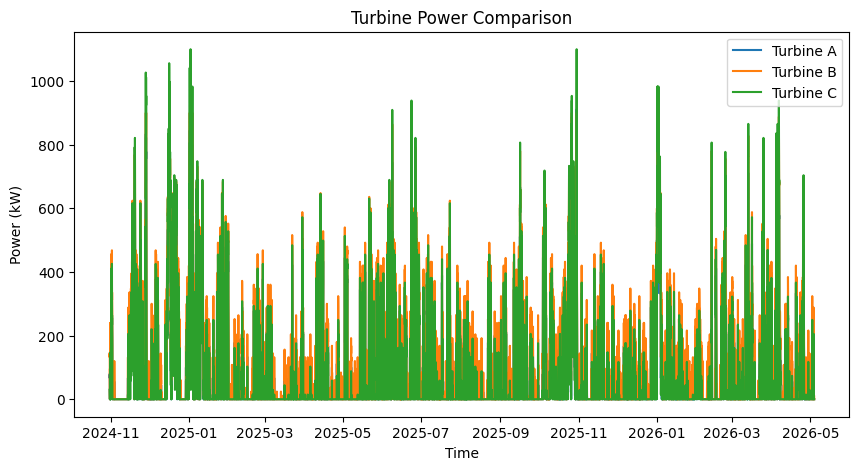

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(wind_df.index, wind_df["power_A_kw"], label="Turbine A")
plt.plot(wind_df.index, wind_df["power_B_kw"], label="Turbine B")
plt.plot(wind_df.index, wind_df["power_C_kw"], label="Turbine C")

plt.title("Turbine Power Comparison")
plt.xlabel("Time")
plt.ylabel("Power (kW)")
plt.legend()

plt.show()


## 6. Energy Production Analysis

We calculate the total energy generated by each turbine over the entire time period.

In [ ]:
total_A = wind_df["power_A_kw"].sum()
total_B = wind_df["power_B_kw"].sum()
total_C = wind_df["power_C_kw"].sum()

print("Total Energy A:", total_A)
print("Total Energy B:", total_B)
print("Total Energy C:", total_C)


Total Energy A: 951022.2222222222
Total Energy B: 1398528.0
Total Energy C: 908908.0


## 7. Environmental Impact (CO2 Emissions)

We estimate the CO2 emissions avoided by using wind energy instead of fossil fuels. 
The calculation is based on total energy production and a standard emission factor (kg CO2 per kWh).
This allows us to evaluate the environmental benefits of different turbine designs.


In [ ]:
co2_factor = 0.4 # kg CO2 per kWh

co2_A = total_A * co2_factor
co2_B = total_B * co2_factor
co2_C = total_C * co2_factor

print(f"CO2 saved by Turbine A: {co2_A:.2f} kg")
print(f"CO2 saved by Turbine B: {co2_B:.2f} kg")
print(f"CO2 saved by Turbine C: {co2_C:.2f} kg")


CO2 saved by Turbine A: 380408.89 kg
CO2 saved by Turbine B: 559411.20 kg
CO2 saved by Turbine C: 363563.20 kg


In [ ]:
# Save processed dataset for Streamlit dashboard
wind_df.to_csv("../data/processed_wind_turbine_results.csv")